In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob as glob
import os as os
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows',None)

Introduction:<br><br>

Majority of research literature focuses on ecosystem models without forecasting. They generally are either descriptive statistics and other forms of analyses that describe that current state of health.

Primary literature assess the complex interactions between natural and artificial or anthropogenic pressures from the perspective of ecosystem response. Due to the complexity of the interconnecting variables that determine the health of ecosystems, forecasting can be trickier. TBEP is the primary estuarine research and conservation group with multiple affiliations to government and academic institutions. More about their efforts can be found in the Readme file of this repository.

TBEP developed 2 indices, TBBI and TBNI - representing the health of the benthic and nekton components of the Tampa Bay estuarine ecosystem.

The first phase of this study aims to develop another index that approaches ecosystem health from the aspect of anthropogenic factors. As a first iteration, this index will be and aggregate weighted index, leaning on the Passche index framework.

Here, I present the Investigation into the Anthrogenic features, demonstrate through EDA various relationships in the current dataset, introduce basic regression models that characterize features and transformations that ultimately allow for the construction of the weighted index.

The "Nekton" jupyter notebook serves as the main notebook that joins all EDA analyses and base models to the dataset at large and will ultimately be where the weighted model is aggregated.

### Loading Data and Formatting Datasets

In [17]:
"""
Using water quality sampling stations to
"""

'\nUsing water quality sampling stations to\n'

In [18]:
os.chdir('J:/Brainstation/BS Git/data/human Imact')

In [19]:
# Middle Tampa Bay Water Quality
mtbwq=pd.read_csv('MTB_WQ.csv',low_memory=False)

In [20]:
hbwq=pd.read_csv('HB_WTQ.csv',low_memory=False)

In [21]:
# Loading in water quality data
# There are 4-5 water bodies that comprise Tampa Bay.
# These 2 data sets are closest in proximmity to the study site.
# Hillsborough Bay (HB)
# Middle Tampa Bay (MTB)

In [22]:
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Actual_Latitude,Actual_Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [23]:
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude_DD,Longitude_DD,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [24]:
mtbwq.isna().sum()

WBodyID                       0
WaterBodyName                 0
DataSource                    0
StationID                     0
StationName                   0
Actual_StationID              0
Actual_Latitude               0
Actual_Longitude              0
DEP_WBID                      0
SampleDate                    0
ActivityDepth             47806
DepthUnits                    0
Parameter                     0
Characteristic             5507
Sample_Fraction          505439
Result_Value                  0
Result_Unit              102440
QACode                   449145
Result_Comment           501969
Original_Result_Value    153389
Original_Result_Unit     167747
dtype: int64

In [25]:
hbwq.isna().sum()

DataSourceName             0
DataSourceCode             0
StationID                  0
ActualStationID      1048575
Latitude_DD                0
Longitude_DD               0
SampleDate                 0
SampleTime                 0
ActivityDepth         766156
ActivityDepthUnit     758436
Characteristic        748461
ResultValue              985
ResultUnit            786325
ValueQualifier       1005190
ResultComment        1035222
WaterbodyID                0
WaterbodyName              0
dtype: int64

In [26]:
mtbwq.Actual_Latitude
mtbwq.columns[[6,7]]

Index(['Actual_Latitude', 'Actual_Longitude'], dtype='object')

In [27]:
# Standardizing some columns between these 2 datasets

In [28]:
hbwq.rename(columns={'Latitude_DD':'Latitude','Longitude_DD':'Longitude'},inplace=True)
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [29]:
# Standardizing some columns between these 2 datasets

In [30]:
mtbwq.rename(columns={'Actual_Latitude':'Latitude','Actual_Longitude':'Longitude'},inplace=True)
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,NaN,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [31]:
hbwq.Characteristic.value_counts()

Characteristic
Temperature, water                               45421
Salinity                                         33622
Specific conductance                             31115
Dissolved oxygen (DO)                            30145
pH                                               29934
                                                 ...  
Manganese                                            2
Nickel                                               2
Zinc                                                 2
Nitrogen, Nitrite (NO2) as N                         2
Anatoxin (toxin produced by blue green algae)        1
Name: count, Length: 61, dtype: int64

** This study uses Organic and Inorganic forms of nitrogen and phosphorous as a proxy for anthropogenic introduction of harmful chemicals into the bay. This study examines these 2 features in 2 main ways:<br>
- As an aggregate statistic that describes the functioning of the bay at large
- The  ratio of organic to inorganic  compounds that describe that extent of anthropogenic and ultimately harmful versions of these compounds introduced.

In [32]:
# looking specifically for the forms of Nitrogen.
# Nitrogen comes in Nitrogen Organic, Nitrogen, Nitrates, Nitrites, Ammonia, Ammonium

# HBWQ - Hillsborough Bay Water Quality
# MTBWQ - Middle Tampa Bay Water Quality

index_1=hbwq.Characteristic.str.contains('Nit,nit').index==True

In [33]:
len(index_1)

1048575

In [34]:
Nit=hbwq.Characteristic.str.contains('Nitrogen')

In [35]:
Nit.head()

0    False
1    False
2    False
3    False
4    False
Name: Characteristic, dtype: object

In [36]:
pho_hb=hbwq.Characteristic.str.contains('Phosph')

In [37]:
hbwq[pho_hb==True]

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
21,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/3/2006,0:00:00,0.2,m,Phosphorus as P,280.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
22,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/3/2006,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.20000,mg/l,NaN,NaN,20005,Hillsborough Bay
84,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/10/2006,0:00:00,0.2,m,Phosphorus as P,230.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
85,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,10/10/2006,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.17000,mg/l,NaN,NaN,20005,Hillsborough Bay
162,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,11/7/2006,0:00:00,0.2,m,Phosphorus as P,170.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014898,Quarterly Routine Water Monitoring,EPC_QUARTERLY,594,NaN,27.819233,-82.382517,10/5/2010,11:51:00,0.5,m,"Phosphorus, phosphate (PO4) as P",0.16800,mg/l,NaN,NaN,20005,Hillsborough Bay
1014901,Quarterly Routine Water Monitoring,EPC_QUARTERLY,594,NaN,27.819233,-82.382517,10/5/2010,11:51:00,0.5,m,Phosphorus as P,340.99999,ug/l,NaN,NaN,20005,Hillsborough Bay
1014904,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,2/10/2015,0:00:00,0.5,m,Phosphorus as P,0.11700,mg/l,J,NaN,20005,Hillsborough Bay
1014909,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,2/13/2001,9:09:00,1.4,m,Phosphorus as P,0.12000,mg/l,NaN,NaN,20005,Hillsborough Bay


### EDA

#### WQI Sample Frequency, Consistency Check

In [38]:
hbwq.SampleDate.str.slice(-4).value_counts().reset_index().sort_values(by='SampleDate')

,SampleDate,count
29,1990,5554
27,1991,6780
22,1992,10118
25,1993,7243
30,1994,5342
28,1995,5786
33,1996,4647
34,1997,4210
32,1998,4774
31,1999,5241


In [39]:
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

In [40]:
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)

In [41]:
hbwq.head(3)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fluorides,1.0,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fecal Coliform,10.0,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Dissolved Solids,27200.0,mg/l,NaN,NaN,20005,Hillsborough Bay


In [42]:
mtbwq.head(3)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,NaN,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l


    SampleDate  count
10           1    419
9            2    439
6            3    462
11           4    346
0            5    530
7            6    455
8            7    450
2            8    499
1            9    500
5           10    481
3           11    491
4           12    482


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

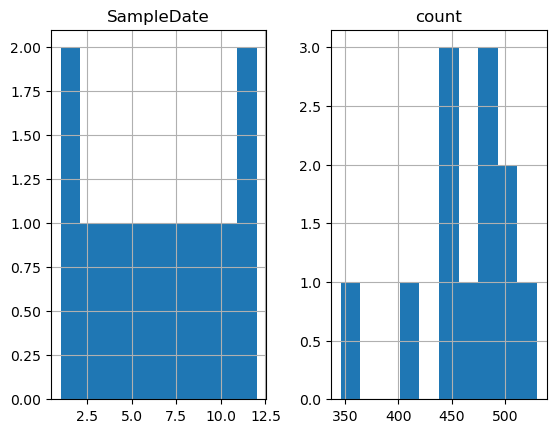

In [43]:
#Look at sample counts over time.
print(hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

    SampleDate  count
6            1    795
7            2    791
9            3    766
10           4    718
2            5    827
4            6    805
8            7    786
1            8    886
3            9    809
0           10    981
11          11    658
5           12    803


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

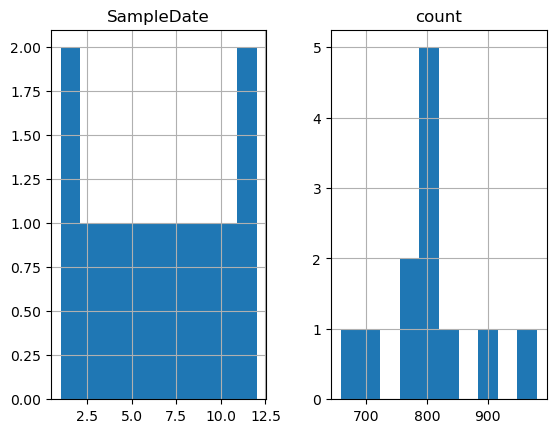

In [44]:
# Checking for distribution of sample counts by month
print(mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

#### Preliminary EDA and processing of subset, 1990

In [45]:
mtbwq1990=mtbwq[mtbwq.SampleDate.dt.year==1990]

In [46]:
mtbwq1990[mtbwq1990.SampleDate.dt.month==1].sort_values(by='SampleDate')

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
510825,20007,Middle Tampa Bay,HCEPC_WQ,32,Tampa Bay Marker 5G,"=""32""",27.7931,-82.570600,1558C,1990-01-03 00:00:00,3.20,m,Cond_umhocm,Specific conductance,NaN,45300.00,umho,NaN,NaN,NaN,NaN
130386,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Turb_ntu,Turbidity,NaN,3.00,NTU,NaN,NaN,NaN,NaN
130385,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Tcoli_100ml,Total Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
130384,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,TKN_ugl,"Nitrogen, Kjeldahl",NaN,680.00,ug/l,NaN,NaN,NaN,NaN
130383,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,4.42,m,Fcoli_100ml,Fecal Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82437,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TP_mgl,Phosphorus as P,NaN,0.52,mg/l,NaN,NaN,0.52,mg/L
82438,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TKN_mgl,"Nitrogen, Kjeldahl",NaN,1.31,mg/l,NaN,NaN,1.31,mg/L
82439,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,TN_mgl,Nitrogen,NaN,1.38,mg/l,C,NaN,1.38,mg/L
82427,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,0.30,m,norg_ugl,"Nitrogen, organic",NaN,1270.00,ug/l,C,NaN,1.27,mg/L


In [47]:
hbwq1990=hbwq[hbwq.SampleDate.dt.year==1990]

In [48]:
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)

In [49]:
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

In [50]:
hbwq1990_samplefreq=hbwq1990.SampleDate.value_counts().reset_index().sort_values(by='SampleDate').reset_index(drop=True)

<Axes: >

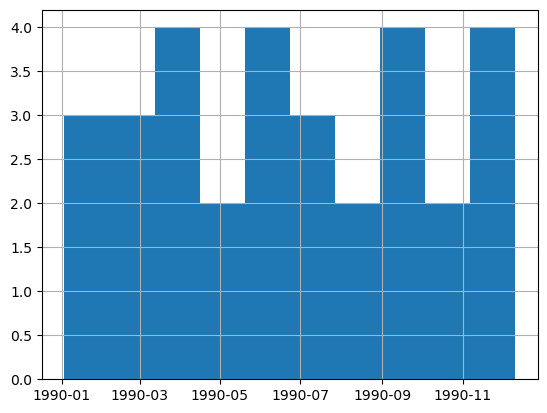

In [51]:
hbwq1990_samplefreq.SampleDate.hist()

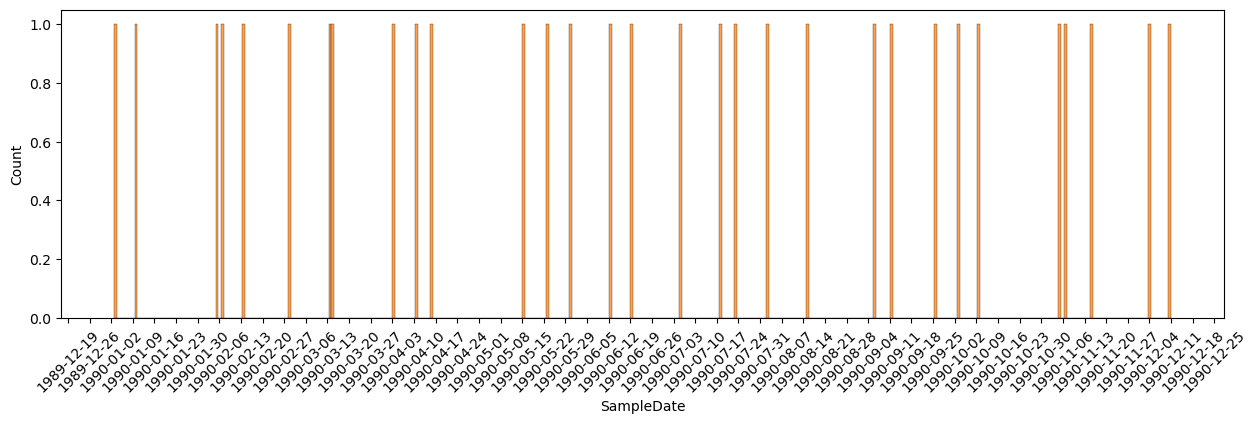

In [52]:
import matplotlib.dates as mdates

plt.figure(figsize=(15,4))
sns.histplot()
ax = sns.histplot(x=hbwq1990_samplefreq.SampleDate,bins=365)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
#plt.xticks(range('1990-01-01','1990-12-31', 365))
plt.show()

In [53]:
hbwq1990

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22449,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22450,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22453,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-03-14,0:00:00,2.59,m,Fecal Coliform,8.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22455,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22457,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-05-16,0:00:00,2.59,m,Fecal Coliform,4.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938257,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-05-31,0:00:00,NaN,NaN,Phosphorus as P,0.55,mg/l,NaN,NaN,20005,Hillsborough Bay
938295,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-08-15,0:00:00,NaN,NaN,"Nitrogen, Kjeldahl",0.77,mg/l,NaN,NaN,20005,Hillsborough Bay
938296,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-08-15,0:00:00,NaN,NaN,"Nitrogen, Kjeldahl",0.75,mg/l,NaN,NaN,20005,Hillsborough Bay
938346,USGS National Water Information System,USGS_NWIS,2.75134E+14,NaN,27.859747,-82.451205,1990-02-07,0:00:00,NaN,NaN,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",0.04,mg/l,NaN,NaN,20005,Hillsborough Bay


In [54]:
# Isolate Nitrates
nitrogen_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Nitr','nitr')==True]
nitrogen_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22768,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Nitrogen,930.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22769,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Nitrogen,1120.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22770,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-03-14,0:00:00,2.59,m,Nitrogen,720.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22771,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,Nitrogen,610.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22772,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-05-16,0:00:00,2.59,m,Nitrogen,940.0,ug/l,NaN,NaN,20005,Hillsborough Bay


#### Isolation of Compounds

The dataset has multiple entries for each sample event. The same sample is analyzed and described in multiple ways. Consequently, data needs to be isolated to get a consistent single data set.

In [55]:
phosphate_hb=hbwq[hbwq.Characteristic.str.contains('Phos','phos')==True]
phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)
phosphate_hb.head(2)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_55644\4096948815.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
21,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,Phosphorus as P,280.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.2,mg/l,NaN,NaN,20005,Hillsborough Bay


In [56]:
phosphate_hb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16091 entries, 21 to 1014911
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   DataSourceName     16091 non-null  object        
 1   DataSourceCode     16091 non-null  object        
 2   StationID          16091 non-null  object        
 3   ActualStationID    0 non-null      float64       
 4   Latitude           16091 non-null  float64       
 5   Longitude          16091 non-null  float64       
 6   SampleDate         16091 non-null  datetime64[ns]
 7   SampleTime         16091 non-null  object        
 8   ActivityDepth      14639 non-null  float64       
 9   ActivityDepthUnit  14633 non-null  object        
 10  Characteristic     16091 non-null  object        
 11  ResultValue        16087 non-null  float64       
 12  ResultUnit         15536 non-null  object        
 13  ValueQualifier     1327 non-null   object        
 14  ResultCo

In [57]:
#Isolate Phosphate
phosphate_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Phos','phos')==True]
phosphate_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
23711,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-12-11,0:00:00,0.91,m,"Phosphorus, phosphate (PO4) as P",0.30,mg/l,NaN,NaN,20005,Hillsborough Bay
25728,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-06-13,0:00:00,1.07,m,Phosphorus as P,0.65,mg/l,NaN,NaN,20005,Hillsborough Bay
25729,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-10-10,0:00:00,0.91,m,Phosphorus as P,0.42,mg/l,NaN,NaN,20005,Hillsborough Bay
25764,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-09-12,0:00:00,2.44,m,Phosphorus as P,0.63,mg/l,NaN,NaN,20005,Hillsborough Bay
25849,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-02-14,0:00:00,1.52,m,Phosphorus as P,0.52,mg/l,NaN,NaN,20005,Hillsborough Bay


In [58]:
pd.concat([nitrogen_1990.Characteristic.value_counts(),nitrogen_1990.ResultUnit.value_counts()],axis=1)

,count,count
"Nitrogen, Kjeldahl",362.0,NaN
Nitrogen,349.0,NaN
"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",338.0,NaN
"Nitrogen, ammonia as N",319.0,NaN
"Nitrogen, organic",311.0,NaN
"Nitrogen, Nitrate (NO3) as N",14.0,NaN
mg/l,NaN,831.0
ug/l,NaN,699.0


##### Phosphates

In [59]:
# Full HB dataset: phosphate_hb

In [60]:
phosphate_hb.ResultUnit.value_counts()

ResultUnit
mg/l    10431
ug/l     5105
Name: count, dtype: int64

In [61]:
phosphate_hb_PO4=phosphate_hb[phosphate_hb.Characteristic.str.contains('PO4')]

In [62]:
phosphate_hb_PO4.ResultUnit.value_counts()

ResultUnit
mg/l    4719
Name: count, dtype: int64

In [63]:
phosphorous_hb_P=phosphate_hb[phosphate_hb.Characteristic== 'Phosphorus as P']

In [64]:
phosphorous_hb_P.ResultUnit.value_counts()

ResultUnit
mg/l    5712
ug/l    5105
Name: count, dtype: int64

In [65]:
phosphorous_hb_P_mg=phosphorous_hb_P[phosphorous_hb_P.ResultUnit=='mg/l']

In [66]:
phosphorous_hb_P_ug=phosphorous_hb_P[phosphorous_hb_P.ResultUnit=='ug/l']

In [67]:
phosphorous_hb_P_mg.head(3)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
25674,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1993-11-09,0:00:00,1.07,m,Phosphorus as P,0.32,mg/l,NaN,NaN,20005,Hillsborough Bay
25675,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1994-10-11,0:00:00,0.91,m,Phosphorus as P,0.50,mg/l,NaN,NaN,20005,Hillsborough Bay
25694,EPC Water Quality Data,HCEPC_WQ,71,NaN,27.876387,-82.413883,2005-05-10,14:48:00,4.92,M,Phosphorus as P,0.27,mg/l,NaN,NaN,20005,Hillsborough Bay


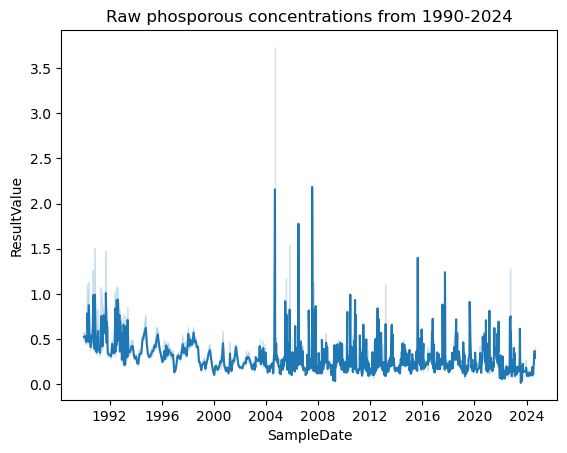

In [70]:
sns.lineplot(x='SampleDate',y='ResultValue',data=phosphorous_hb_P_mg)
plt.title('Raw phosporous concentrations from 1990-2024')
plt.show()

In [71]:
# Formatting df as needed
phosphorous_hb_P_mg['month']=phosphorous_hb_P_mg.SampleDate.dt.month

In [72]:
phosphorous_hb_P_mg['year']=phosphorous_hb_P_mg.SampleDate.dt.year

In [73]:
phosphorous_hb_P_mg=phosphorous_hb_P_mg.sort_values(by='SampleDate')

In [74]:
# Getting aggregate statistics to describe larger relationships
P_mean=phosphorous_hb_P_mg.groupby(['year','month','ResultUnit']).ResultValue.mean().reset_index()

In [75]:
# Getting plottable Year-Month format X-axis
P_mean['ym']=P_mean.year.astype(str)+'_'+P_mean.month.astype(str)

Text(0, 0.5, 'Phosphorous Concentration (mg/L)')

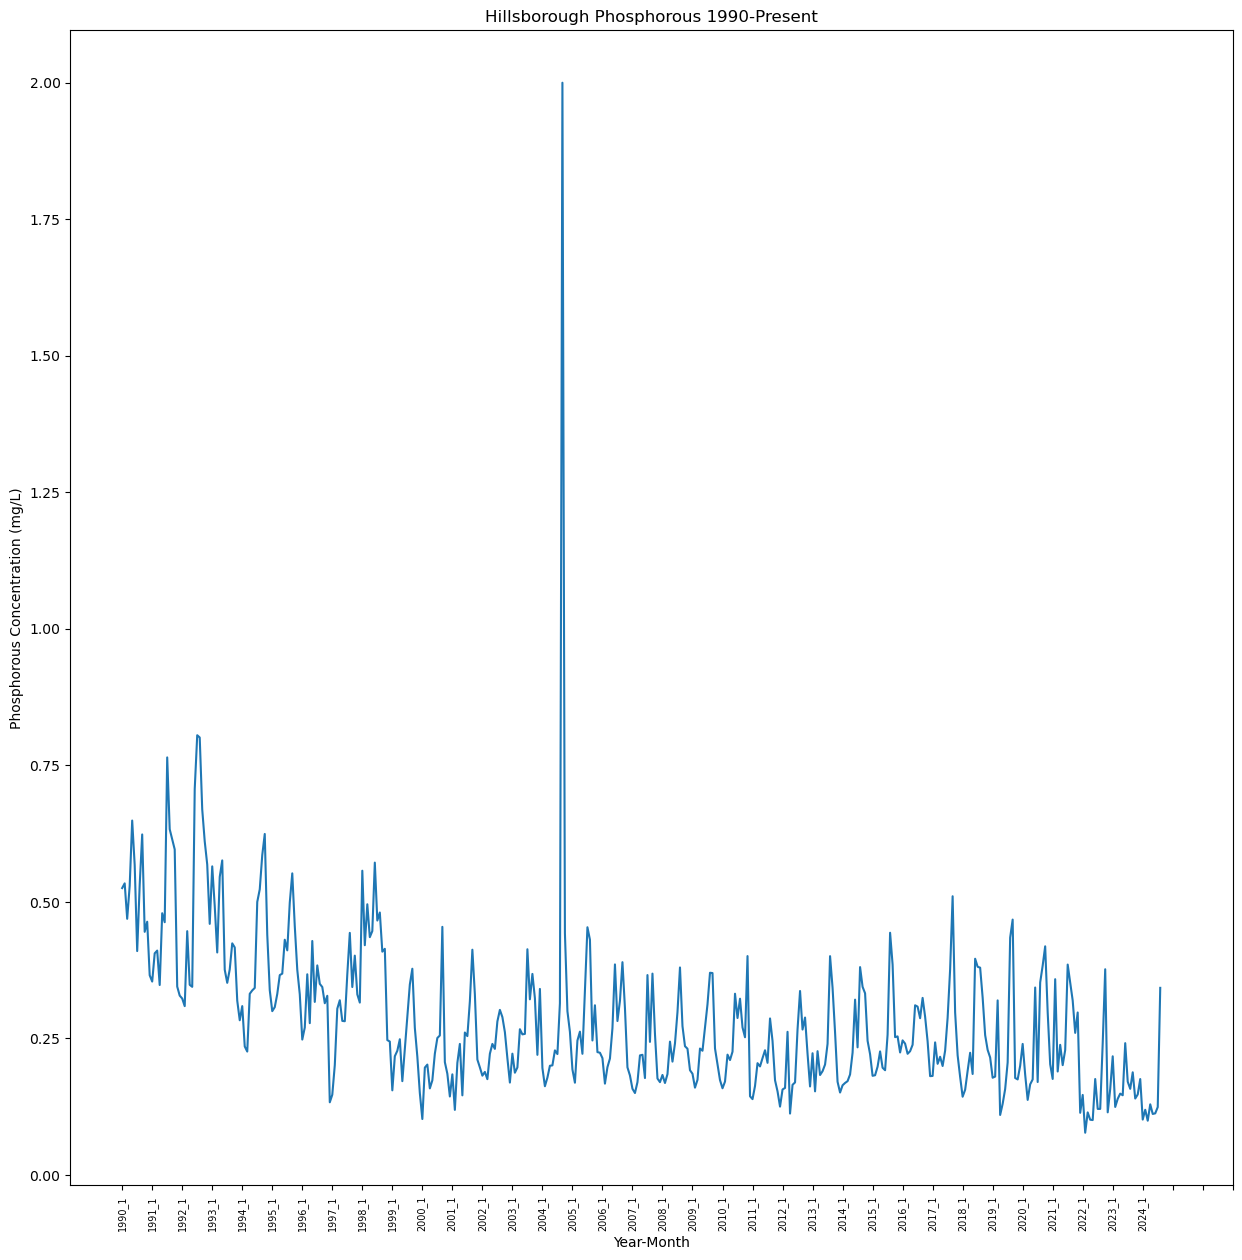

In [76]:
plt.figure(figsize=(15,15))
sns.lineplot(x='ym',y='ResultValue',data=P_mean)
plt.title('Hillsborough Phosphorous 1990-Present')
plt.xlabel('Year-Month')
plt.xticks(rotation=90,fontsize='x-small')
plt.xticks(np.arange(0,450,step=12))
plt.ylabel('Phosphorous Concentration (mg/L)')

In [77]:
sns.lineplot(x='month',y='ResultValue',data=PO4_mean)

NameError: name 'PO4_mean' is not defined

##### Nitrogen

In [78]:
nitrates=hbwq[hbwq.Characteristic.isin(['Nitrogen','Nitrite','ammonia','Nitrate'])]

In [79]:
hbwq.isna().sum()

DataSourceName             0
DataSourceCode             0
StationID                  0
ActualStationID      1048575
Latitude                   0
Longitude                  0
SampleDate                 0
SampleTime                 0
ActivityDepth         766156
ActivityDepthUnit     758436
Characteristic        748461
ResultValue              985
ResultUnit            786325
ValueQualifier       1005190
ResultComment        1035222
WaterbodyID                0
WaterbodyName              0
dtype: int64

In [80]:
#These columns have too many missing data points - and are not useful for this iteration. They cannot be imputed
# or do not add value
hb_wq_nit_iso=hbwq.drop(columns=hbwq.columns[[3,14,13,6,15]])

In [81]:
hb_wq_nit_iso.Characteristic=hb_wq_nit_iso.Characteristic.str.lower()

Isolate columns of interest.

In [82]:
"""
Key Nitrogen columns:
[16
,17
,18
,43
,45
,57
,60
61]
"""

"""
Key Phosphorous columns:
21
22


"""

'\nKey Phosphorous columns:\n21\n22\n\n\n'

In [83]:
hb_wq_nit_iso.Characteristic = hb_wq_nit_iso.Characteristic.str.lower()

In [84]:
# Need to look at all the variables/compounds classified in the column and dataset. Notably, the forms of nitrogen
counter=0
for x in hb_wq_nit_iso.Characteristic.unique():
    print(f'Col: {counter}: {x}')
    counter+=1

Col: 0: fluorides
Col: 1: fecal coliform
Col: 2: dissolved solids
Col: 3: dissolved oxygen saturation
Col: 4: dissolved oxygen (do)
Col: 5: depth
Col: 6: chlorophyll a, corrected for pheophytin
Col: 7: chloride
Col: 8: calcium
Col: 9: bod, biochemical oxygen demand
Col: 10: apparent color
Col: 11: alkalinity, carbonate as caco3
Col: 12: turbidity
Col: 13: total suspended solids (tss)
Col: 14: total organic carbon (toc)
Col: 15: magnesium
Col: 16: nitrogen, ammonia as n
Col: 17: nitrogen, kjeldahl
Col: 18: nitrogen, nitrite (no2) + nitrate (no3) as n
Col: 19: ph
Col: 20: pheophytin-a
Col: 21: phosphorus as p
Col: 22: phosphorus, phosphate (po4) as p
Col: 23: potassium
Col: 24: salinity
Col: 25: secchi disk depth
Col: 26: sodium
Col: 27: specific conductance
Col: 28: sulfur, sulfate (so4) as so4
Col: 29: bod, carbonaceous
Col: 30: temperature, water
Col: 31: total coliform
Col: 32: chlorophyll a, uncorrected for pheophytin
Col: 33: depth, bottom
Col: 34: true color
Col: 35: cloud cover
C

In [85]:
hb_wq_nit_iso.isna().sum()

DataSourceName            0
DataSourceCode            0
StationID                 0
Latitude                  0
Longitude                 0
SampleTime                0
ActivityDepth        766156
ActivityDepthUnit    758436
Characteristic       748461
ResultValue             985
ResultUnit           786325
WaterbodyName             0
dtype: int64

In [86]:
unique_n=hb_wq_nit_iso.Characteristic.unique()
counter=0
for x in unique_n:
    print(f'Characteristic [{counter}]: {x}')
    counter+=1

Characteristic [0]: fluorides
Characteristic [1]: fecal coliform
Characteristic [2]: dissolved solids
Characteristic [3]: dissolved oxygen saturation
Characteristic [4]: dissolved oxygen (do)
Characteristic [5]: depth
Characteristic [6]: chlorophyll a, corrected for pheophytin
Characteristic [7]: chloride
Characteristic [8]: calcium
Characteristic [9]: bod, biochemical oxygen demand
Characteristic [10]: apparent color
Characteristic [11]: alkalinity, carbonate as caco3
Characteristic [12]: turbidity
Characteristic [13]: total suspended solids (tss)
Characteristic [14]: total organic carbon (toc)
Characteristic [15]: magnesium
Characteristic [16]: nitrogen, ammonia as n
Characteristic [17]: nitrogen, kjeldahl
Characteristic [18]: nitrogen, nitrite (no2) + nitrate (no3) as n
Characteristic [19]: ph
Characteristic [20]: pheophytin-a
Characteristic [21]: phosphorus as p
Characteristic [22]: phosphorus, phosphate (po4) as p
Characteristic [23]: potassium
Characteristic [24]: salinity
Charac

In [87]:
hbwq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   DataSourceName     1048575 non-null  object        
 1   DataSourceCode     1048575 non-null  object        
 2   StationID          1048575 non-null  object        
 3   ActualStationID    0 non-null        float64       
 4   Latitude           1048575 non-null  float64       
 5   Longitude          1048575 non-null  float64       
 6   SampleDate         1048575 non-null  datetime64[ns]
 7   SampleTime         1048575 non-null  object        
 8   ActivityDepth      282419 non-null   float64       
 9   ActivityDepthUnit  290139 non-null   object        
 10  Characteristic     300114 non-null   object        
 11  ResultValue        1047590 non-null  float64       
 12  ResultUnit         262250 non-null   object        
 13  ValueQualifier     43385 no

In [88]:
hbwq[hbwq.Characteristic.str.contains('Nitr' or 'nitr' or 'Amm' or 'amm')]

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
nitrates.to_csv('nitrates_hb')

** Getting values for nitrates from Middle Tampa Bay **

In [91]:
# First pass at isolating data of interest
mtb_nitrates=mtbwq[mtbwq.Characteristic.isin(['Nitrogen','Nitrite','ammonia','Nitrate'])]

In [92]:
mtb_nitrates

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,ActivityDepth,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
8,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10 00:00:00,NaN,m,TN_ugl,Nitrogen,NaN,460.000,ug/l,NaN,NaN,NaN,NaN
23,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10 00:00:00,NaN,m,TN_mgl,Nitrogen,NaN,0.460,mg/l,NaN,NaN,NaN,NaN
1242,20007,Middle Tampa Bay,WIN_21FLHILL,11,11,"=""11""",27.812901,-82.478897,1558C,2020-02-11 00:00:00,0.90,m,TN_ugl,Nitrogen,Total,339.000,ug/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN
1243,20007,Middle Tampa Bay,WIN_21FLHILL,11,11,"=""11""",27.812901,-82.478897,1558C,2020-02-11 00:00:00,0.90,m,TN_mgl,Nitrogen,Total,0.339,mg/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN
1244,20007,Middle Tampa Bay,WIN_21FLHILL,11,11,"=""11""",27.812901,-82.478897,1558C,2020-06-09 00:00:00,1.35,m,TN_mgl,Nitrogen,Total,0.238,mg/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544152,20007,Middle Tampa Bay,PINELLAS,E6,Weedon Island South Area/Shore Acres,"=""E6-C-12-8""",27.811150,-82.594590,1558C,2012-12-05 11:11:00,0.22,m,TN_mgl,Nitrogen,NaN,0.260,mg/l,NaN,Water Institute Calculated,NaN,NaN
544184,20007,Middle Tampa Bay,PINELLAS,E6,Weedon Island South Area/Shore Acres,"=""E6-A-12-8""",27.791200,-82.607350,1558C,2012-12-05 11:56:00,0.21,m,TN_ugl,Nitrogen,NaN,340.000,ug/l,NaN,Water Institute Calculated,NaN,NaN
544185,20007,Middle Tampa Bay,PINELLAS,E6,Weedon Island South Area/Shore Acres,"=""E6-A-12-8""",27.791200,-82.607350,1558C,2012-12-05 11:56:00,0.21,m,TN_mgl,Nitrogen,NaN,0.340,mg/l,NaN,Water Institute Calculated,NaN,NaN
544255,20007,Middle Tampa Bay,WIN_21FLGW,59865,Z4-CN-16003 UNNAMED CANAL,"=""59865""",27.758901,-82.428693,1725B,2022-01-19 00:00:00,0.30,m,TN_ugl,Nitrogen,Total,945.000,ug/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN


##### Combining Nit/Phos

In [97]:
nitrates_total=pd.read_csv('nitrates_hb.csv')

In [98]:
nitrates_total=nitrates_total[nitrates_total.ResultUnit=='ug/l']

In [99]:
mtb_nitrates.to_csv('nitrates_mtb2.csv')

In [106]:
#columns of interest
#here solely for reference
"""
hbwq['WaterbodyName','Latitude','Longitutude','SampleDate','Characteristic','ResultValue','Result','ActivityDepth','ActivityDepthUnit']
"""

"\nhbwq['WaterbodyName','Latitude','Longitutude','SampleDate','Characteristic','ResultValue','Result','ActivityDepth','ActivityDepthUnit']\n"

In [107]:
pwd

'J:\\Brainstation\\BS Git\\data\\human Imact'

In [108]:
nitrates=pd.read_csv('nitrates.csv')

In [109]:
# Reformat Dates
nitrates.SampleDate=pd.to_datetime(nitrates.SampleDate)

In [110]:
# Extract Month-Year
nitrates['month']=nitrates.SampleDate.dt.month
nitrates['year']=nitrates.SampleDate.dt.year

# Standardize units to mg for comparison scale with Phosphates
nitrates.ResultValue2=nitrates.ResultValue/1000
nitrates.ResultUnit2='mg/l'

In [111]:
nitrates.head(5)

,Unnamed: 0,DataSourceCode,StationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ResultValue2,ResultUnit2,WaterbodyName,month,year
0,33671,USGS_NWIS,NaN,27.710030,-82.546763,1971-06-01,NaN,NaN,m,Nitrogen,780.0,ug/l,0.78,mg/l,Middle Tampa Bay,6,1971
1,33675,USGS_NWIS,NaN,27.807804,-82.453983,1971-06-01,NaN,NaN,m,Nitrogen,1010.0,ug/l,1.01,mg/l,Middle Tampa Bay,6,1971
2,34903,USGS_NWIS,NaN,27.758639,-82.508984,1971-06-01,NaN,NaN,m,Nitrogen,710.0,ug/l,0.71,mg/l,Middle Tampa Bay,6,1971
3,34948,USGS_NWIS,NaN,27.666421,-82.557597,1971-06-01,NaN,NaN,m,Nitrogen,960.0,ug/l,0.96,mg/l,Middle Tampa Bay,6,1971
4,34899,USGS_NWIS,NaN,27.824192,-82.580653,1971-06-02,NaN,NaN,m,Nitrogen,690.0,ug/l,0.69,mg/l,Middle Tampa Bay,6,1971


In [112]:
# Getting plottable Year-Month format X-axis
nitrates['ym']=nitrates.year.astype(str)+'_'+nitrates.month.astype(str)

In [113]:
nitrates

,Unnamed: 0,DataSourceCode,StationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ResultValue2,ResultUnit2,WaterbodyName,month,year,ym
0,33671,USGS_NWIS,NaN,27.710030,-82.546763,1971-06-01,NaN,NaN,m,Nitrogen,780.0,ug/l,0.780,mg/l,Middle Tampa Bay,6,1971,1971_6
1,33675,USGS_NWIS,NaN,27.807804,-82.453983,1971-06-01,NaN,NaN,m,Nitrogen,1010.0,ug/l,1.010,mg/l,Middle Tampa Bay,6,1971,1971_6
2,34903,USGS_NWIS,NaN,27.758639,-82.508984,1971-06-01,NaN,NaN,m,Nitrogen,710.0,ug/l,0.710,mg/l,Middle Tampa Bay,6,1971,1971_6
3,34948,USGS_NWIS,NaN,27.666421,-82.557597,1971-06-01,NaN,NaN,m,Nitrogen,960.0,ug/l,0.960,mg/l,Middle Tampa Bay,6,1971,1971_6
4,34899,USGS_NWIS,NaN,27.824192,-82.580653,1971-06-02,NaN,NaN,m,Nitrogen,690.0,ug/l,0.690,mg/l,Middle Tampa Bay,6,1971,1971_6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17010,11000,WIN_21FLHILL,NaN,27.662500,-82.563904,2024-08-21,NaN,2.57,m,Nitrogen,158.0,ug/l,0.158,mg/l,Middle Tampa Bay,8,2024,2024_8
17011,11202,WIN_21FLHILL,NaN,27.708401,-82.609200,2024-08-21,NaN,3.25,m,Nitrogen,158.0,ug/l,0.158,mg/l,Middle Tampa Bay,8,2024,2024_8
17012,11610,WIN_21FLHILL,NaN,27.751101,-82.571800,2024-08-21,NaN,2.11,m,Nitrogen,213.0,ug/l,0.213,mg/l,Middle Tampa Bay,8,2024,2024_8
17013,11712,WIN_21FLHILL,NaN,27.729000,-82.498703,2024-08-21,NaN,0.97,m,Nitrogen,163.0,ug/l,0.163,mg/l,Middle Tampa Bay,8,2024,2024_8


In [114]:
# Getting rid of unusable columns
# Columns also don't add any value.
nitrates.isna().sum()
nitrates.drop(columns=['StationID','SampleTime'],inplace=True)
nitrates.drop(columns=nitrates.columns[0],inplace=True)

In [115]:
nMTB=nitrates[nitrates.WaterbodyName=='Middle Tampa Bay']

In [116]:
nHB=nitrates[nitrates.WaterbodyName=='Hillsborough Bay']

In [117]:
nitrates=nitrates[nitrates.year>1989]
nitrates.head(5)

,DataSourceCode,Latitude,Longitude,SampleDate,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ResultValue2,ResultUnit2,WaterbodyName,month,year,ym
3451,HCEPC_WQ,27.826100,-82.567500,1990-01-03,4.42,m,Nitrogen,690.0,ug/l,0.69,mg/l,Middle Tampa Bay,1,1990,1990_1
3452,EPC_ROUTINE_MONITORING,27.826099,-82.567497,1990-01-03,4.40,m,Nitrogen,690.0,ug/l,0.69,mg/l,Middle Tampa Bay,1,1990,1990_1
3453,EPC_ROUTINE_MONITORING,27.793200,-82.570701,1990-01-03,3.20,m,Nitrogen,550.0,ug/l,0.55,mg/l,Middle Tampa Bay,1,1990,1990_1
3454,EPC_ROUTINE_MONITORING,27.811800,-82.523201,1990-01-03,1.80,m,Nitrogen,540.0,ug/l,0.54,mg/l,Middle Tampa Bay,1,1990,1990_1
3455,HCEPC_WQ,27.811700,-82.523100,1990-01-03,1.83,m,Nitrogen,540.0,ug/l,0.54,mg/l,Middle Tampa Bay,1,1990,1990_1


In [118]:
N_means=nitrates.groupby(['year','month','ym'])[['ResultValue2','ActivityDepth','Latitude','Longitude']].mean().reset_index()

In [119]:
N_means.shape

(416, 7)

In [120]:
P_mean.shape

(416, 5)

In [121]:

P_mean.rename(columns={'ResultValue':'Phos',
                      'year':'pyear',
                      'month':'pmonth',
                      'ResultUnit':'pResultUnit',
                      'ym':'p_ym'
                      },inplace=True)

In [122]:
P_mean.head(3)

,pyear,pmonth,pResultUnit,Phos,p_ym
0,1990,1,mg/l,0.525385,1990_1
1,1990,2,mg/l,0.534000,1990_2
2,1990,3,mg/l,0.469091,1990_3


In [123]:
print(P_mean.shape)
print(N_means.shape)

(416, 5)
(416, 7)


Creating joined tables for both Nitrogen and Phosphate values. Values have been aggregated and averaged, standardized to a monthly average

In [124]:
NP_means=pd.concat([N_means,P_mean],axis=1)

In [125]:
# check for consistency
(NP_means.ym==NP_means.p_ym).value_counts()

True    416
Name: count, dtype: int64

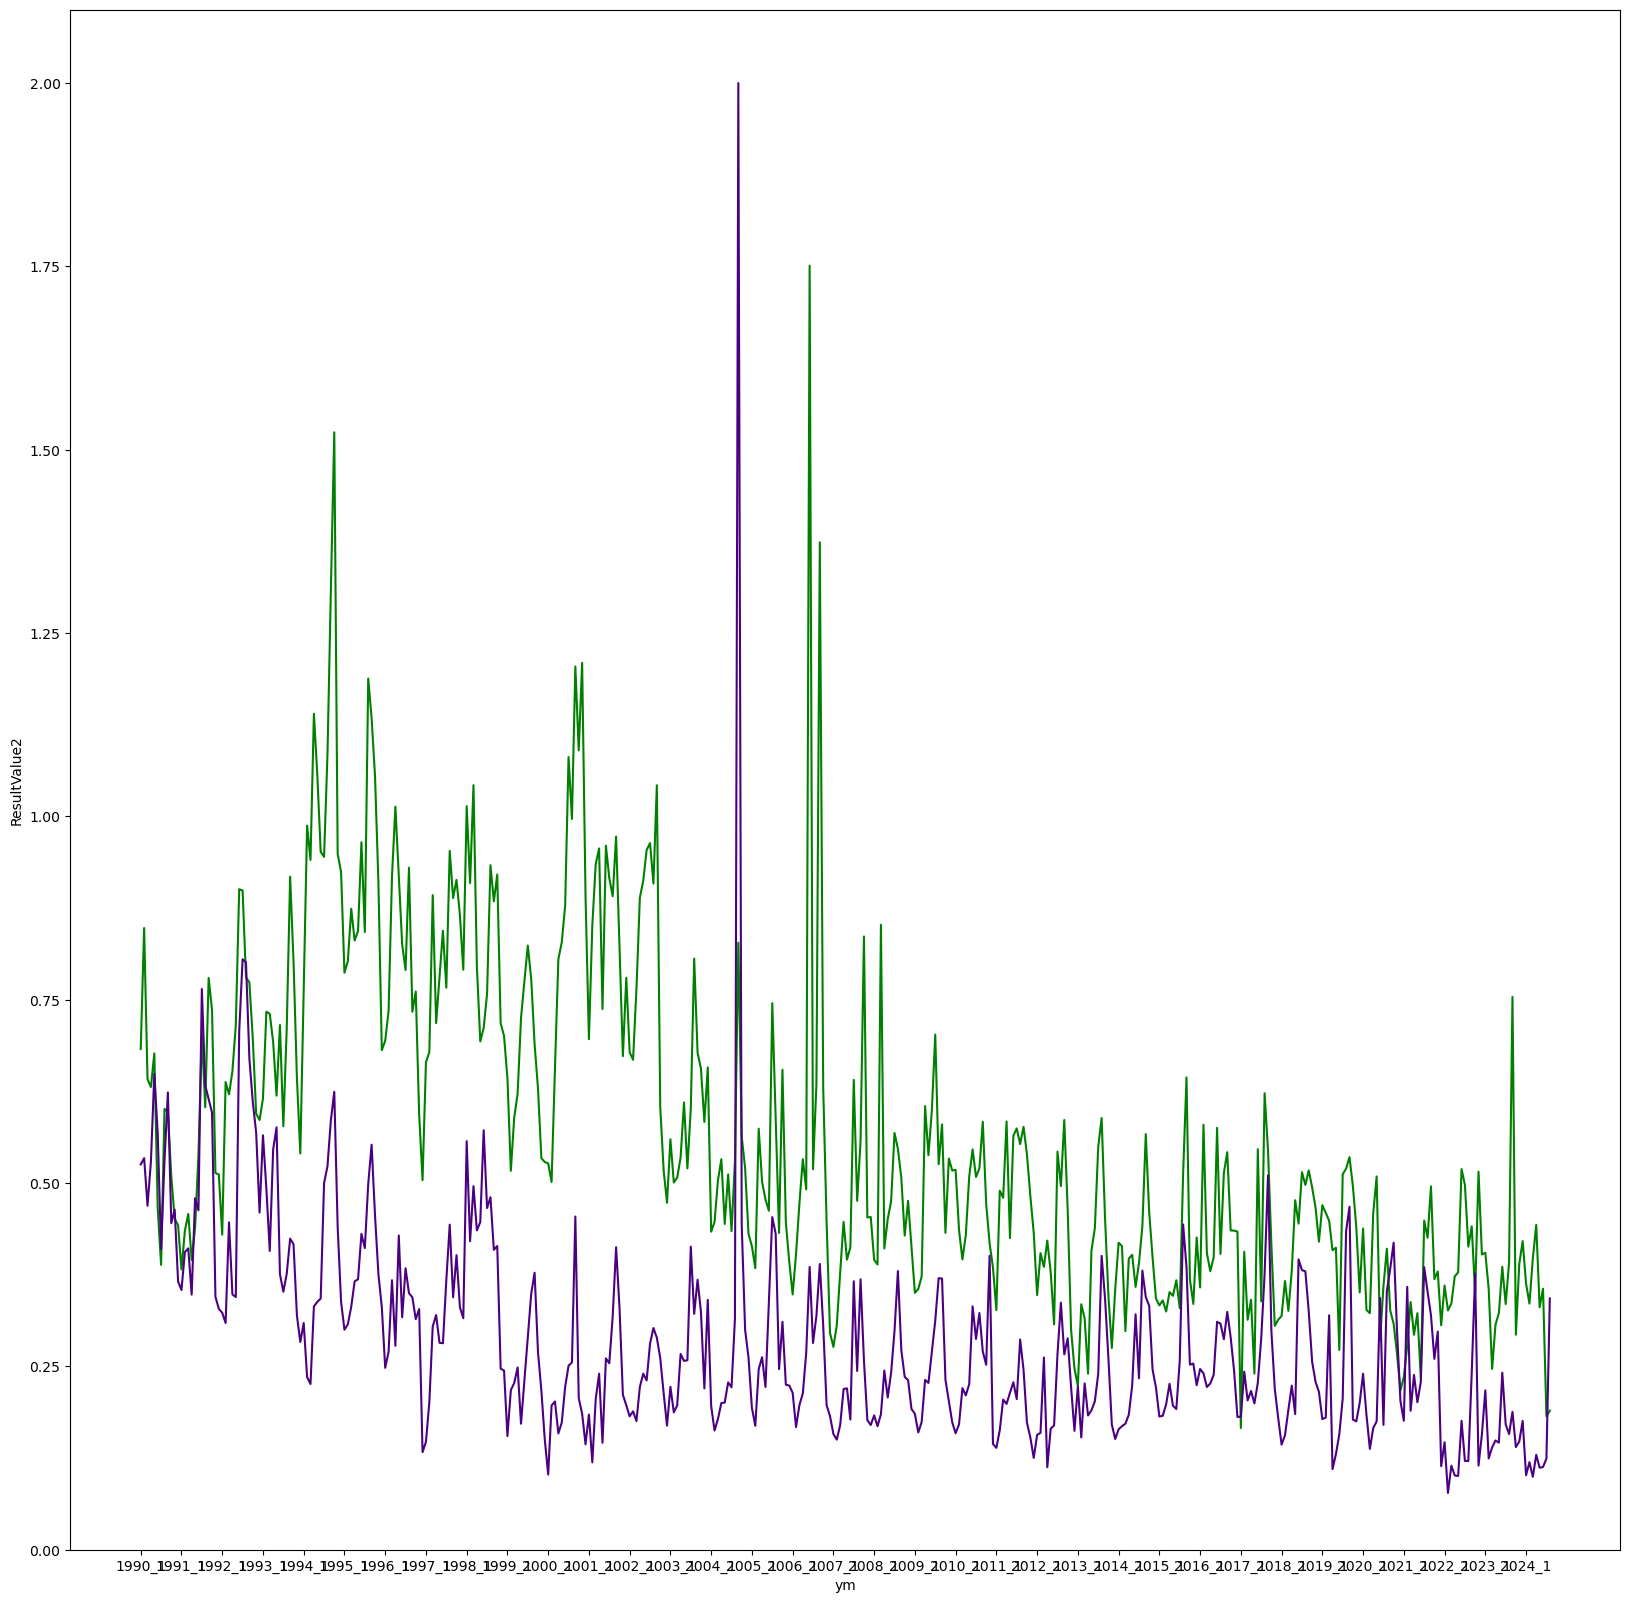

In [126]:
fig, ax = plt.subplots(figsize=(20,20))
#plt.figure(figsize=(15,15))
sns.lineplot(x='ym',y='ResultValue2',data=NP_means,ax=ax,color='green')
#ax1=ax.twinx()
sns.lineplot(x='ym',y='Phos',data=NP_means,color='indigo')
#plt.xticks(rotation=,fontsize='x-small')
plt.xticks(np.arange(0,420, step = 12))
plt.ylim(0,2.1)
plt.show()

There is a definite relationship between the two variables and they both exhibit seasonality; however, intepreting them with respect to the other features may prove more difficult

In [127]:
pwd

'J:\\Brainstation\\BS Git\\data\\human Imact'

In [128]:
NP_means.to_csv('nitrate_phosphate_totals_1990_2024.csv')

<Axes: xlabel='ym', ylabel='Count'>

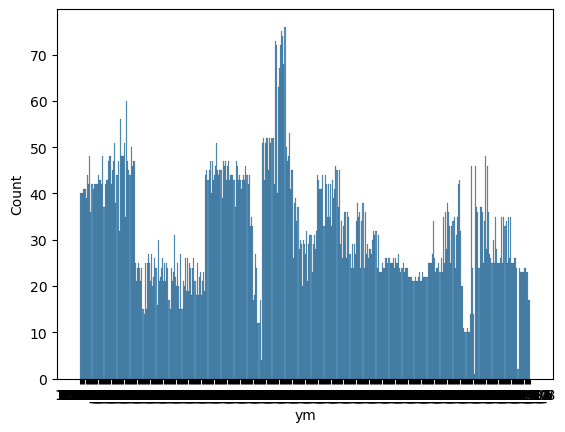

In [129]:
#plt.subplot(111)
sns.histplot(nitrates[nitrates.year>1989].ym)
#plt.subplot(313)


<Axes: xlabel='ym', ylabel='Count'>

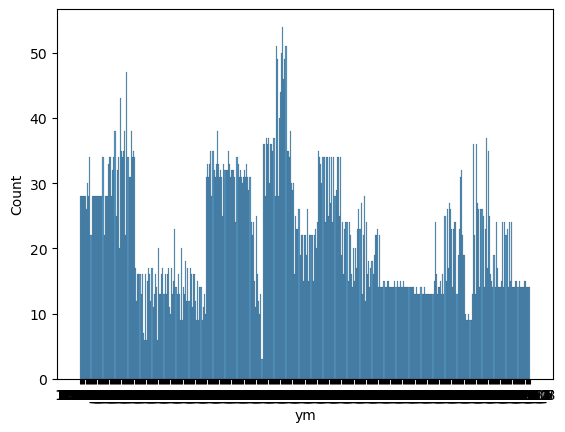

In [130]:
sns.histplot(nMTB[nMTB.year>1989].ym)

<Axes: xlabel='ym', ylabel='Count'>

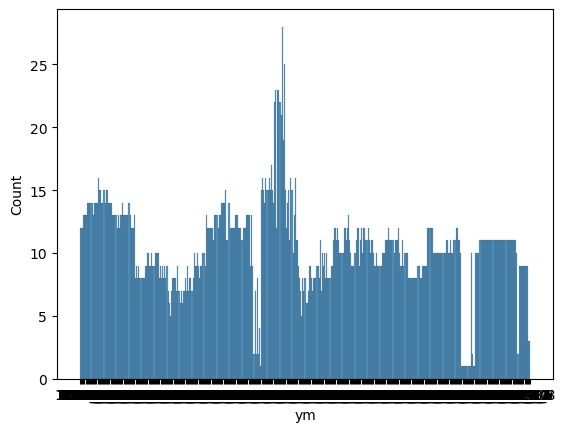

In [131]:
sns.histplot(nHB[nHB.year>1989].ym)

In [132]:
nitrates.WaterbodyName.value_counts()

WaterbodyName
Middle Tampa Bay    9194
Hillsborough Bay    4370
Name: count, dtype: int64

In [133]:
nitrates.groupby(['year','month','ym'])[['ActivityDepth','ResultValue2']].mean().reset_index()

,year,month,ym,ActivityDepth,ResultValue2
0,1990,1,1990_1,2.319250,0.682750
1,1990,2,1990_2,2.451250,0.847750
2,1990,3,1990_3,2.362000,0.641500
3,1990,4,1990_4,2.224878,0.630976
4,1990,5,1990_5,2.543902,0.676829
...,...,...,...,...,...
411,2024,4,2024_4,2.052083,0.442958
412,2024,5,2024_5,2.039130,0.330565
413,2024,6,2024_6,2.219565,0.355957
414,2024,7,2024_7,2.494118,0.182000


SOME literature suggested this approach as a consequence of poor performance of other models; however, this may be a rather irrelevant test

__** This test was ultimately disregarded. Exported CSVs were imported in the NEKTON notebook for further processing **__

### Development 99.206KM COASTLINE NOT INCLUDING WATERWAYS

Here is the introduction of construction, real estate and development influences on the bay.
It is difficult to retrieve consisten data for land usage, development and coastal construction, due to privacy rights, hidden data and more.

Possible methods:
- Aerial, geospatial analysis. Land use, development can be assessed through aerial imagery taken over time. With scale, images can be sectioned and assessed. This requires a great deal of effort to utilize specific geospatial data. This form  of investigation is covered by another notebook.
- Examination of land usage is a component but *can* require extensive work so it is being included here.
- Construction. Looking at permits, construction dates and even sales can inform development rates.

Based on data availability, this study chose to look at the construction date of individual parcels of land in coastal regions.

A critical concept to note is an understanding of how to describe coastal development and the underlying concepts, particularly in an estuarine system. Coastal contsruction should be evaluated by development around watersheds that feed into the main body of water. These have an equal weighted influence on anthropogenic pressures on the local marine ecosystem.

Data Description:

The CSVs read in below cover sections of the coastline and specifically attributes of individual plots of land. The primary features of interest are
- Property Acreage
- Year Built
- Number of structures built
- Land type
- Total square footage of structure

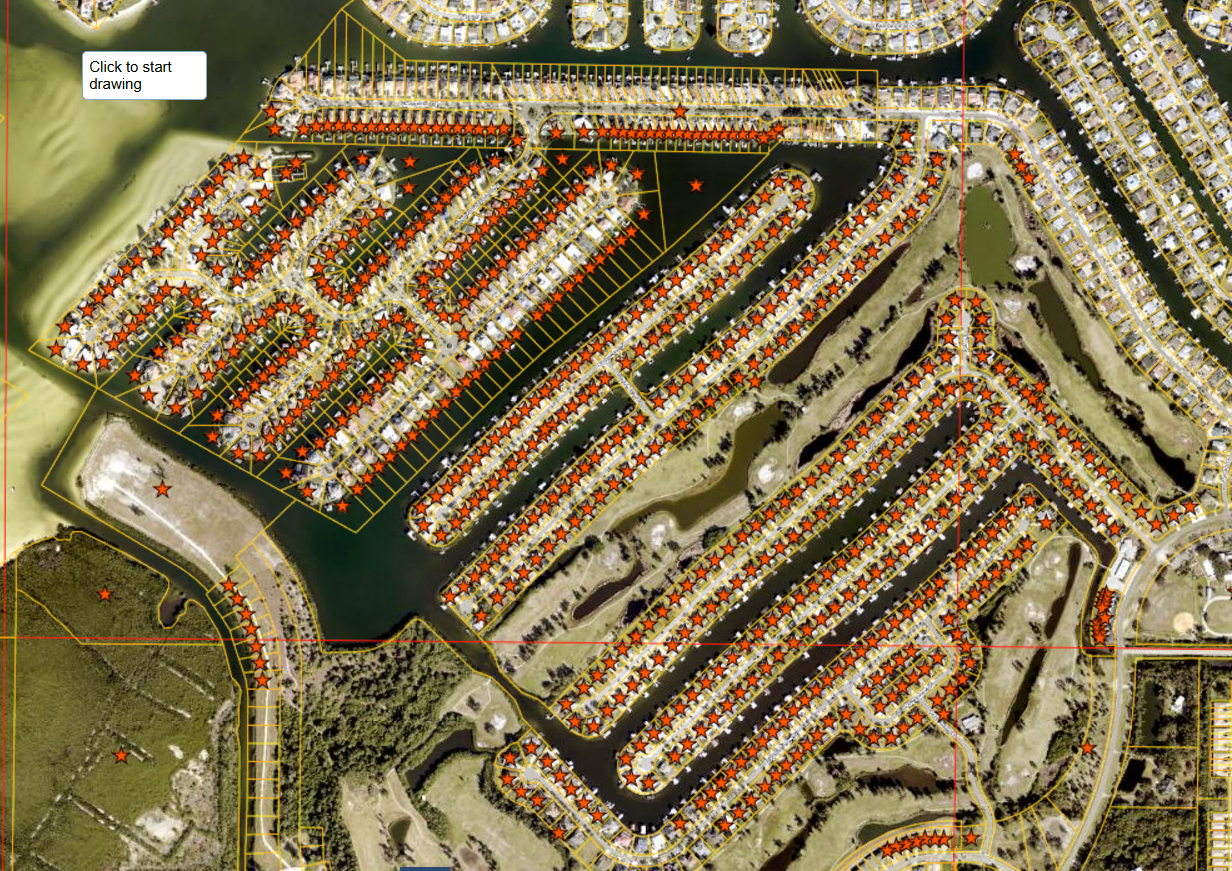

In [188]:
os.chdir('J:/Brainstation/BS Git/Property Records')

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'J:/Brainstation/BS Git/Property Records'

In [175]:
x=os.listdir()

In [176]:
AB_1=pd.read_csv('AB_1.csv')
AB_2=pd.read_csv('AB_BLVD_SPIT_1.csv')
AB_3=pd.read_csv('AB_Central_1.csv')
AB_4=pd.read_csv('AB_INTSXN_1.csv')
AB_5=pd.read_csv('AB_SOUTH_1.csv')
AB_6=pd.read_csv('AB_SOUTH_2.csv')
AB_7=pd.read_csv('AB_SPIT_1.csv')
GIB_8=pd.read_csv('GIB_MAIN_1.csv')

In [177]:
RIV_1=pd.read_csv('RIV_W_1.csv')

In [178]:
os.chdir('J:/Brainstation/Capstone Git/Property Records')

In [179]:
AB_1.head(2)

,Strap,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,LastSaleDate,LastSalePrice,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,YearBuilt,BldgCost,SqrFoot,HtdSqrFoot,Neighborhood,CensusTract,Lat,Lng
0,U-17-31-19-1T4-000000-00011.0,PARSONS AARON A,Y,1,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,10/10/2018 12:00:00 AM,504000.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022,3.0,3,5,1,1987,256523.0,3958,2882,227006,1.205701e+11,27.780714,-82.417778
1,U-18-32-19-ZZZ-000001-79190.0,RIVERSIDE MHP LLC,N,28,2814 - Parking lots commercial,3.01,1501 Susie Cir,Ruskin,33570.0,312 SAVANNAH OAKS PL,SEFFNER,FL,33584,682667.0,0.0,4/2/2021 12:00:00 AM,1095000.0,1382400.0,1382400.0,RSC-6,32S,18.0,19E,ZZZ,000001,79190.0,576610000,3.0,5,4,8,1966,80946.0,3826,3412,227001,1.205701e+11,27.703499,-82.446503


In [180]:
AB_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    1000 non-null   object 
 1   Folio                    1000 non-null   int64  
 2   PIN                      1000 non-null   object 
 3   PropertyType             912 non-null    object 
 4   Owner1                   1000 non-null   object 
 5   Owner2                   515 non-null    object 
 6   MailingAddress1          1000 non-null   object 
 7   MailingAddress2          33 non-null     object 
 8   MailingCity              999 non-null    object 
 9   MailingState             1000 non-null   object 
 10  MailingZip               994 non-null    object 
 11  MailingCountry           6 non-null      object 
 12  SiteAddress              971 non-null    object 
 13  SiteCity                 997 non-null    object 
 14  SiteZip                  

In [181]:
dflist=[
AB_1,
AB_2,
AB_3,
AB_4,
AB_5,
AB_6,
AB_7,
GIB_8,
RIV_1]

In [182]:
dfprop=pd.DataFrame(data=AB_2)

In [190]:
# Combine all sections of property data
# dfprop = 'Dataframe: Property'
for x in dflist:
    print(x.shape)
    dfprop=pd.concat([dfprop,x],axis=0)

(500, 39)
(1000, 45)
(1000, 45)
(121, 45)
(1000, 45)
(660, 45)
(505, 45)
(1000, 45)
(1000, 45)


In [184]:
dfprop1=dfprop.copy()

In [185]:
dfprop.head(5)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,1506200.0,1506200.0,0.0,0.0,0.0,0.0,1506200.0,1458728.0,1458728.0,2016-10-25,6720000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,33602-5600,NaN,6650 DICKMAN RD,APOLLO BEACH,33572.0,19.51,No,COM AT SE COR OF SEC 16 N 89 DEG 24 MIN 10 SEC...,0 FT N 00 DEG 32 MIN 38 SEC E 30 FT FOR POB N ...,EG 24 MIN 10 SEC W 1235.13 FT N 00 DEG 45 MIN ...,SEC E 702.42 FT N 88 DEG 48 MIN 46 SEC E 140.7...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,5.0,6.0,6.0,1.0,4.0,2014,528573.0,528573.0,3943661.0,214709.0,33167.0,59269.0,4686943.0,4570922.0,4570922.0,1973-01-01,100.0,NaN,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,NaN,NaN,NaN,APOLLO BEACH,33572.0,110.66,No,APOLLO BEACH SUB FLAMINGO CANAL AND OTHER CANA...,"B 34-41, PB 34-40, PB34-98, PB 35-41, PB 35-98...","44-90, PB 42-7, PB 37-79 SECTION 20, 21 AND 2...",-19,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,33602-3597,NaN,501 APOLLO BEACH BLVD,APOLLO BEACH,33572.0,14.82,No,RUSKIN TOMATO FARMS THAT PT OF TRS 20 & 27 DES...,BEG 261.88 FT S & 50 FT W OF NE COR OR NE 1/4...,UN S 1123.15 FT TO N BDRY OF APOLLO BEACH BLVD...,81.15 FT N 1125.33 FT AND E 581.15 FT TO BEG,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,1981,3386382.0,3386382.0,12909615.0,443031.0,93256.0,93256.0,16739028.0,8986443.0,0.0,1980-07-01,33000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,504 ELSBERRY RD,APOLLO BEACH,33572.0,0.17,No,RUSKIN TOMATO FARMS W 71 FT OF E 91 FT OF N 10...,OF LOT 20,NaN,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0

In [186]:
dfprop.shape

(7786, 79)

In [187]:
AB_1.head(1)

,Strap,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,LastSaleDate,LastSalePrice,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,YearBuilt,BldgCost,SqrFoot,HtdSqrFoot,Neighborhood,CensusTract,Lat,Lng
0,U-17-31-19-1T4-000000-00011.0,PARSONS AARON A,Y,1,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,10/10/2018 12:00:00 AM,504000.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022,3.0,3,5,1,1987,256523.0,3958,2882,227006,1.205701e+11,27.780714,-82.417778


In [151]:
AB_2.head(1)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,1931151SF000000009000U,515550000,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0,0.0,0.0,0.0,0.0,0,1506200,1506200,0,0,0,0,1506200,1458728,1458728,2016-10-25,6720000,Vacant,Unqualified,NaN


In [152]:
AB_3.head(3)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,193109ZZZ000001736500U,514610000,U-09-31-19-ZZZ-000001-73650.0,PREFAB MTL BLD,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,33601-0111,NaN,603 BIG BEND RD,GIBSONTON,33534,416.07,No,9 AND 10 31 19 FRAC N 1/2 SEC 9 AND WLY EXT TH...,F DESC AS BEG AT INTERS OF E AND W 1/4 LINE WI...,SEC BDRY AND RUN W ALONG 1/4 SEC LINE AND ITS...,EXT 3960 FT N 2636.19 FT TO PT ON WLY PROJECT...,UNPLATTED,Gibsonton Area S of River,UNINCORPORATED,U,38,167.0,50.0,0.0,0.0,1985,12773011,12773011,31474408,10257988,593167,624374,54505407,54505407,54505407,1981-12-01,100,NaN,Unqualified,NaN
1,193114ZZZ000001743500U,515310000,U-14-31-19-ZZZ-000001-74350.0,WRHSE DISTRIB,FUTERNICK ASSOCIATES,NaN,1430 S DIXIE HWY UNIT 1226,NaN,CORAL GABLES,FL,33146-3176,NaN,6861N 41 HWY,APOLLO BEACH,33572-,13.92,No,THAT PART OF NW 1/4 OF SW 1/4 DESC AS : BEG AT...,ER OF WLY R/W LINE OF ACL RR AND E BDRY LINE O...,23 AND RUN N 28 DEG 36 MIN 28 SEC E ALONG RR ...,.75 FT N 89 DEG 32 MIN 36 SEC W 704.83 FT N 84...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,2,2.0,2.0,0.0,0.0,2019,1688906,1688906,9551460,623000,86761,91823,7578800,7578800,7578800,2017-08-25,2662500,Vacant,Unqualified,NaN
2,1931151SF000000003000U,515410000,U-15-31-19-1SF-000000-00300.0,SERVICE/REPAIR SHOP,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,33601-0111,NaN,490 BIG BEND RD,APOLLO BEACH,33572,136.96,No,RUSKIN TOMATO FARMS LOT 3 LESS E 450 FT AND LE...,90 FT ... LOT 4 LESS N 90 FT ... LOT 6 LESS N...,FT OF E 450 FT ... LOT 7,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1,0.0,1.0,0.0,0.0,1960,5868642,5868642,78204,31098,4071,4071,5977944,5977944,5977944,1982-02-01,430500,Improved,Unqualified,NaN


In [153]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7786 entries, 0 to 999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    7786 non-null   object 
 1   Folio                    7286 non-null   float64
 2   PIN                      7286 non-null   object 
 3   PropertyType             6229 non-null   object 
 4   Owner1                   7286 non-null   object 
 5   Owner2                   3635 non-null   object 
 6   MailingAddress1          7286 non-null   object 
 7   MailingAddress2          331 non-null    object 
 8   MailingCity              7280 non-null   object 
 9   MailingState             7286 non-null   object 
 10  MailingZip               7248 non-null   object 
 11  MailingCountry           41 non-null     object 
 12  SiteAddress              6990 non-null   object 
 13  SiteCity                 7261 non-null   object 
 14  SiteZip                  7258 

In [154]:
"""
Columns for Selection Pressure analysis

3,
8,
14,
15,
25,
26,
30,
36,
40,
42

"""

'\nColumns for Selection Pressure analysis\n\n3,\n8,\n14,\n15,\n25,\n26,\n30,\n36,\n40,\n42\n\n'

In [155]:
dfprop.drop_duplicates(inplace=True)

In [156]:
dfprop=dfprop[dfprop.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [157]:
RIV_1=RIV_1[RIV_1.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [158]:
RIV_1.shape

(1000, 11)

In [159]:
dfprop.shape

(6358, 11)

In [160]:
dfprop1

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,1506200.0,1506200.0,0.0,0.0,0.0,0.0,1506200.0,1458728.0,1458728.0,2016-10-25,6720000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,33602-5600,NaN,6650 DICKMAN RD,APOLLO BEACH,33572.0,19.51,No,COM AT SE COR OF SEC 16 N 89 DEG 24 MIN 10 SEC...,0 FT N 00 DEG 32 MIN 38 SEC E 30 FT FOR POB N ...,EG 24 MIN 10 SEC W 1235.13 FT N 00 DEG 45 MIN ...,SEC E 702.42 FT N 88 DEG 48 MIN 46 SEC E 140.7...,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,5.0,6.0,6.0,1.0,4.0,2014,528573.0,528573.0,3943661.0,214709.0,33167.0,59269.0,4686943.0,4570922.0,4570922.0,1973-01-01,100.0,NaN,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,NaN,NaN,NaN,APOLLO BEACH,33572.0,110.66,No,APOLLO BEACH SUB FLAMINGO CANAL AND OTHER CANA...,"B 34-41, PB 34-40, PB34-98, PB 35-41, PB 35-98...","44-90, PB 42-7, PB 37-79 SECTION 20, 21 AND 2...",-19,UNPLATTED,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,33602-3597,NaN,501 APOLLO BEACH BLVD,APOLLO BEACH,33572.0,14.82,No,RUSKIN TOMATO FARMS THAT PT OF TRS 20 & 27 DES...,BEG 261.88 FT S & 50 FT W OF NE COR OR NE 1/4...,UN S 1123.15 FT TO N BDRY OF APOLLO BEACH BLVD...,81.15 FT N 1125.33 FT AND E 581.15 FT TO BEG,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,1981,3386382.0,3386382.0,12909615.0,443031.0,93256.0,93256.0,16739028.0,8986443.0,0.0,1980-07-01,33000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,504 ELSBERRY RD,APOLLO BEACH,33572.0,0.17,No,RUSKIN TOMATO FARMS W 71 FT OF E 91 FT OF N 10...,OF LOT 20,NaN,NaN,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0

In [161]:
dfprop=pd.concat([dfprop,RIV_1])

In [162]:
dfprop.isna().sum()

Strap                    0
PropertyType          1676
SiteCity               522
SiteZip                523
Acreage                500
TotalNumBuildings      500
TotalStories           500
YearBuilt                0
TotalGrossAreaSqFt     500
LastSaleDate           164
VacantImproved         818
dtype: int64

In [191]:
# To be consildated into higher aggregate categories: Residential, Commercial, Industrial, Other
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     10799
MANUFACTURED HOME (AYB > 1976)     2373
TOWNHOUSE                          1403
MOBILE HOME (AYB < 1977)            859
CONDOMINIUM                         333
OFFICE <3 STORY                     164
COMM/CONDO 2                        110
PREFAB MTL BLD                       96
DUPLEX/TRIPLEX/QUADPLX/ETC           79
WRHSE - STORAGE                      75
RETAIL STRIP CENTER                  72
NOT CALCULATING                      61
CLUBHOUSE                            59
AUTO SERVICE/REPAIR GARAGE           39
STORE RETAIL                         37
CONVENIENCE STORE                    33
MEDICAL OFFICE                       25
WRHSE DISTRIB                        24
MFG LIGHT                            22
APARTMENT <4 STORY                   19
RESTAURANT                           19
SERVICE/REPAIR SHOP                  18
MODULAR HOME                         18
CHURCH                               15
REST FAST FOOD             

In [192]:
# Slight cleaning of the data
# Some of the grids overlapped so these rows must be accounted for
dfprop.duplicated().value_counts()

True     15000
False     6358
Name: count, dtype: int64

In [193]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21358 entries, 0 to 999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    21358 non-null  object 
 1   Folio                    19858 non-null  float64
 2   PIN                      19858 non-null  object 
 3   PropertyType             16863 non-null  object 
 4   Owner1                   19858 non-null  object 
 5   Owner2                   9875 non-null   object 
 6   MailingAddress1          19858 non-null  object 
 7   MailingAddress2          927 non-null    object 
 8   MailingCity              19842 non-null  object 
 9   MailingState             19858 non-null  object 
 10  MailingZip               19756 non-null  object 
 11  MailingCountry           111 non-null    object 
 12  SiteAddress              19028 non-null  object 
 13  SiteCity                 19789 non-null  object 
 14  SiteZip                  1978

In [194]:
dfprop.isna().sum()

Strap               0
Folio            1500
PIN              1500
PropertyType     4495
Owner1           1500
                ...  
SqrFoot         19858
HtdSqrFoot      19858
CensusTract     19876
Lat             19858
Lng             19858
Length: 79, dtype: int64

In [195]:
dfprop.Acreage

0       41.89
1       19.51
2      110.66
3       14.82
4        0.17
        ...  
995      0.21
996      0.59
997      5.28
998      0.84
999    427.38
Name: Acreage, Length: 21358, dtype: float64

In [196]:
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     10799
MANUFACTURED HOME (AYB > 1976)     2373
TOWNHOUSE                          1403
MOBILE HOME (AYB < 1977)            859
CONDOMINIUM                         333
OFFICE <3 STORY                     164
COMM/CONDO 2                        110
PREFAB MTL BLD                       96
DUPLEX/TRIPLEX/QUADPLX/ETC           79
WRHSE - STORAGE                      75
RETAIL STRIP CENTER                  72
NOT CALCULATING                      61
CLUBHOUSE                            59
AUTO SERVICE/REPAIR GARAGE           39
STORE RETAIL                         37
CONVENIENCE STORE                    33
MEDICAL OFFICE                       25
WRHSE DISTRIB                        24
MFG LIGHT                            22
APARTMENT <4 STORY                   19
RESTAURANT                           19
SERVICE/REPAIR SHOP                  18
MODULAR HOME                         18
CHURCH                               15
REST FAST FOOD             

In [197]:
dfprop.PropertyType.isna().sum()

4495

In [198]:
dfprop.PropertyType.fillna('undefined',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_55644\2890697567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfprop.PropertyType.fillna('undefined',inplace=True)


In [199]:
dfprop.duplicated().sum()

15000

In [207]:
# Get rid of redundant data rows|
dfprop.drop_duplicates(inplace=True)

In [208]:
dfprop.isna().sum()

Strap              0
Folio            500
PIN              500
PropertyType       0
Owner1           500
                ... 
SqrFoot         5858
HtdSqrFoot      5858
CensusTract     5864
Lat             5858
Lng             5858
Length: 79, dtype: int64

In [209]:
dfprop.duplicated().value_counts()

False    6358
Name: count, dtype: int64

In [221]:
dfprop[dfprop.SiteCity.isna()==True]

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
994,193122C6N000000000010U,539650622.0,U-22-31-19-C6N-000000-00001.0,REST FAST FOOD,S B APOLLO BEACH LLC,NaN,405 18TH AVE,NaN,INDIAN ROCKS BEACH,FL,33785,NaN,6184N US HIGHWAY 41,NaN,NaN,0.84,No,APOLLO RETAIL LOT 1,NaN,NaN,NaN,APOLLO RETAIL,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,2021,378454.0,378454.0,738110.0,70064.0,2550.0,2814.0,1199100.0,1199100.0,1199100.0,2022-03-15,3300000.0,Improved,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,193122C6N000000000020U,539650624.0,U-22-31-19-C6N-000000-00002.0,MEDICAL OFFICE,FARMINGTON AVENUE REALTY GROUP LLC,LUBLIN ASSOCIATES NO 2 LLC,1237 GORDON RIVER TRL,NaN,NAPLES,FL,34105,NaN,6182N US 41 HWY,NaN,NaN,0.70,No,APOLLO RETAIL LOT 2,NaN,NaN,NaN,APOLLO RETAIL,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,2.0,1.0,0.0,0.0,2021,345166.0,345166.0,1255866.0,52288.0,4830.0,4830.0,1503100.0,1503100.0,1503100.0,2021-12-16,4150000.0,Improved,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,193122C6N000000000030U,539650626.0,U-22-31-19-C6N-000000-00003.0,MEDICAL OFFICE,BW APOLLO VENTURE II LLC,NaN,ATTN: ACCOUNTS PAYABLE,3301 W GANDY BLVD,TAMPA,FL,33611-,NaN,6182N US 41 HWY,NaN,NaN,0.69,No,APOLLO RETAIL LOT 3,NaN,NaN,NaN,APOLLO RETAIL,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,0.0,0.0,2021,333889.0,333889.0,1215534.0,54097.0,4550.0,4620.0,1585900.0,1585900.0,1585900.0,2020-10-02,1375000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,U-17-31-19-1T4-000000-00011.0,NaN,NaN,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/10/2018 12:00:00 AM,504000.0,NaN,NaN,NaN,PARSONS AARON A,Y,1.0,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022.0,3.0,3.0,5.0,1.0,256523.0,3958.0,2882.0,1.205701e+11,27.780714,-82.417778
1,U-18-32-19-ZZZ-000001-79190.0,NaN,NaN,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4/2/2021 12:00:00 AM,1095000.0,NaN,NaN,NaN,RIVERSIDE MHP LLC,N,28.0,2814 - Parking lots commercial,3.01,1501 Susie Cir,Ruskin,33570.0,312 SAVANNAH OAKS PL,SEFFNER,FL,33584,682667.0,0.0,1382400.0,1382400.0,RSC-6,32S,18.0,19E,ZZZ,000001,79190.0,576610000.0,3.0,5.0,4.0,8.0,80946.0,3826.0,3412.0,1.205701e+11,27.703499,-82.446503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,192922ZZZ000001494603U,43492

In [211]:
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0]

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
35,1931211TM000001000220U,531990000.0,U-21-31-19-1TM-000001-00022.0,SINGLE FAMILY,EDGAR DALE S,NaN,457 FLAMINGO DR,NaN,APOLLO BEACH,FL,33572-2519,NaN,457 FLAMINGO DR,APOLLO BEACH,33572.0,0.24,Yes,APOLLO BEACH UNIT ONE PART ONE LOT 22 BLOCK 1,NaN,NaN,NaN,APOLLO BEACH UNIT ONE PART ONE,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,3.0,2.0,1977,277200.0,277200.0,186482.0,28568.0,1457.0,2149.0,492250.0,197154.0,147154.0,2002-03-22,175900.0,NaN,Qualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,1931211TM000006000090U,533250000.0,U-21-31-19-1TM-000006-00009.0,SINGLE FAMILY,BARBER CYNTHIA J,NaN,477 FAIRFAX LN,NaN,APOLLO BEACH,FL,33572-2502,NaN,477 FAIRFAX LN,APOLLO BEACH,33572.0,0.23,Yes,APOLLO BEACH UNIT ONE PART ONE LOT 9 BLOCK 6,NaN,NaN,NaN,APOLLO BEACH UNIT ONE PART ONE,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,2.0,1.0,1959,87300.0,87300.0,124887.0,22365.0,1462.0,2194.0,234552.0,88119.0,33119.0,2001-12-18,70400.0,NaN,Qualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,1931211TM000017000280U,536700000.0,U-21-31-19-1TM-000017-00028.0,SINGLE FAMILY,TIPPINS HENRY TRUSTEE,TIPPINS PATRICIA TRUSTEE,3430 W SHELL POINT RD,NaN,RUSKIN,FL,33570-3031,NaN,513N FLORIDA CIR,APOLLO BEACH,33572.0,0.18,No,APOLLO BEACH UNIT ONE PART ONE LOT 28 BLOCK 17,NaN,NaN,NaN,APOLLO BEACH UNIT ONE PART ONE,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,2.0,1.0,1971,67500.0,67500.0,126920.0,3401.0,1200.0,1400.0,197821.0,141607.0,141607.0,2001-01-10,100.0,NaN,Qualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,1931211TM000017000300U,536720000.0,U-21-31-19-1TM-000017-00030.0,SINGLE FAMILY,WETZEL DEBORAH LYNNE,NaN,521 FLORIDA CIR N,NaN,APOLLO BEACH,FL,33572-2528,NaN,521N FLORIDA CIR,APOLLO BEACH,33572.0,0.18,Yes,APOLLO BEACH UNIT ONE PART ONE LOT 30 BLOCK 17,NaN,NaN,NaN,APOLLO BEACH UNIT ONE PART ONE,Apollo Beach Area # 1,UNINCORPORATED,U,1.0,1.0,1.0,2.0,1.0,1971,67500.0,67500.0,133486.0,0.0,910.0,1868.0,200986.0,54138.0,25000.0,2002-04-16,100.0,NaN,Qualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,U-17-31-19-1T4-000000-00011.0,NaN,NaN,undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/10/2018 12:00:00 AM,504000.0,NaN,NaN,NaN,PARSONS AARON A,Y,1.0,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,APOLLO BEACH,FL,33572,203700.0,104435.0,674590.0,402525.0,PD,31S,17.0,19E,1T4,000000,00011.0,520915022.0,3.0,3.0,5.0,1.0,256523.0,3958.0,2882.0,1.205701e+11,27.780714,-82.417778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [223]:
# not all columns are relevant and their NaN, null or 0 status is not important
dfprop.isna().sum()

Strap              0
Folio            500
PIN              500
PropertyType       0
Owner1           500
                ... 
SqrFoot         5858
HtdSqrFoot      5858
CensusTract     5864
Lat             5858
Lng             5858
Length: 79, dtype: int64

In [224]:
# Improved plots that have been misclassified
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_55644\1555862745.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)


In [225]:
# Looking for common traits - perhaps it speaks to why these properties were misclassified and and relevance
dfprop[dfprop.YearBuilt==0].PropertyType.unique()

array(['undefined', 'CONDOMINIUM', 'TOWNHOUSE'], dtype=object)

Primary features of interest for simple model are Year Built, Acreage, totalGrossAreaSqft.

Understanding the relationship between development per property and population density and growth will be a calculated feature used in the construction of the HII-aquatic index.

### Housing, Population Density and Change

The impact of coastal development extends beyond the shoreline. In an estuarine environment, the watersheds that feed into the estuary (or in the case the bay) are equally important. Using a highway as a physical boundary overlapped with a map of the various watersheds, a representative set of properties, the type, their acreage and the year that they were built will be used as an estimate and proxy for coastline development.  Based on research literature, concentration of non-organic nitrates and phosphates will serve as a proxy for the introduction of artificial damaging compounds - however, in the construction of more complex models, more granular data can be used.

In [226]:
## New Construction estimates by year

In [227]:
dfprop.head(1)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,MailingZip,MailingCountry,SiteAddress,SiteCity,SiteZip,Acreage,Homestead,Legal1,Legal2,Legal3,Legal4,Subdivision,Neighborhood,TaxDistrict,Municipality,TotalNumBuildings,TotalUnits,TotalStories,TotalBedrooms,TotalBathrooms,YearBuilt,TotalLandValue,TotalLandValue1,TotalBuildingValue,TotalExtraFeaturesValue,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,MailCity,MailState,MailZip,LandVal,TotalExemptions,AppVal,AssVal,Zoning,TownShip,Section,Range,SubDivision,Block,Lot,AltKey,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,515550000.0,U-15-31-19-1SF-000000-00900.0,undefined,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,33601-0111,NaN,1,APOLLO BEACH,33572.0,41.89,No,RUSKIN TOMATO FARMS LOT 15 LESS E 360.27 FT AN...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THERE...,1/2 OF LOT 14 LESS W 524.90 FT THEREOF AND TH...,1/2 OF CLOSED R/W FOR NOONAN RD ABUTTING THEREON,RUSKIN TOMATO FARMS,Apollo Beach Area # 2,UNINCORPORATED,U,0.0,0.0,0.0,0.0,0.0,0,1506200.0,1506200.0,0.0,0.0,0.0,0.0,1506200.0,1458728.0,1458728.0,2016-10-25,6720000.0,Vacant,Unqualified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [228]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6358 entries, 0 to 999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    6358 non-null   object 
 1   Folio                    5858 non-null   float64
 2   PIN                      5858 non-null   object 
 3   PropertyType             6358 non-null   object 
 4   Owner1                   5858 non-null   object 
 5   Owner2                   2851 non-null   object 
 6   MailingAddress1          5858 non-null   object 
 7   MailingAddress2          272 non-null    object 
 8   MailingCity              5854 non-null   object 
 9   MailingState             5858 non-null   object 
 10  MailingZip               5829 non-null   object 
 11  MailingCountry           33 non-null     object 
 12  SiteAddress              5609 non-null   object 
 13  SiteCity                 5841 non-null   object 
 14  SiteZip                  5840 

In [229]:
dfyearbuilt=dfprop[dfprop.YearBuilt>1988].groupby('YearBuilt').YearBuilt.count()

In [230]:
len(dfyearbuilt)

36

In [231]:
# Get annual change of homes built on hillsborough bay coast from 1990-present
perchange=[]
year=1989
year1=[]
x_base=[]
x1=[]
for x in range(1989,1989+len(dfyearbuilt)):
    if x==0:
        continue
    elif x==1988+len(dfyearbuilt):
        break
    else:
        perchange.append(round((dfyearbuilt[x+1]/dfyearbuilt[x])*100,3))
        x_base.append(dfyearbuilt[x])
        x1.append(dfyearbuilt[x+1])
    year+=1
    year1.append(year)

In [232]:
perchange[0:5]

[91.892, 63.235, 158.14, 135.294, 75.0]

In [233]:
dfperchange=pd.DataFrame()
dfperchange['percentchange']=perchange

In [234]:
dfperchange['x']=x_base
dfperchange['x+1']=x1
dfperchange['year']=year1

In [235]:
dfperchange.head(5)

,percentchange,x,x+1,year
0,91.892,74,68,1990
1,63.235,68,43,1991
2,158.140,43,68,1992
3,135.294,68,92,1993
4,75.000,92,69,1994


In [236]:
dfprop.LastSaleDate=pd.to_datetime(dfprop.LastSaleDate)

ValueError: time data "10/10/2018 12:00:00 AM" doesn't match format "%Y-%m-%d", at position 1000. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [240]:
dfperchange=pd.concat([dfperchange,dfperchange_unit.iloc[:,0:3]],axis=1)

NameError: name 'dfperchange_unit' is not defined

In [237]:
dfprop[dfprop.YearBuilt>1989].groupby(['YearBuilt']).TotalNumBuildings.agg(['min', 'max', 'std', 'sum'])

,min,max,std,sum
YearBuilt,,,,
1990,1.0,4.0,0.443977,70.0
1991,1.0,2.0,0.152499,44.0
1992,1.0,1.0,0.000000,64.0
1993,1.0,7.0,0.929039,104.0
1994,1.0,1.0,0.000000,69.0
1995,1.0,1.0,0.000000,103.0
1996,1.0,2.0,0.130734,118.0
1997,1.0,2.0,0.115470,76.0
1998,1.0,3.0,0.294418,107.0


In [238]:
# Get annual change of Total buildings built on hillsborough bay coast from 1990-present
perchange_build=[]
year_build=1989
year1_build=[]
x_base1=[]
x2=[]
for x in range(1989,1989+len(dftotalunit)):
    if x==0:
        continue
    elif x==1988+len(dfyearbuilt):
        break
    else:
        perchange_build.append(round((dftotalunit[x+1]/dftotalunit[x])*100,3))
        x_base1.append(dftotalunit[x])
        x2.append(dftotalunit[x+1])
    year_build+=1
    year1_build.append(year_build)

NameError: name 'dftotalunit' is not defined

In [239]:
# Describes number of houses built in subset data, total number of units per built structure
# Multi-unit buildings have an increased environmental impact per individual parcel
dfperchange_unit

NameError: name 'dfperchange_unit' is not defined

In [ ]:
##### Population

In [422]:
os.chdir('J:\\Brainstation\\Capstone Git')

In [424]:
dftraffic=pd.read_csv('MaritimeTraffic_TB.csv')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_10352\3424837237.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  dftraffic=pd.read_csv('MaritimeTraffic_TB.csv')


In [241]:
##### Current Working Space
## Maritime Traffic may not be taken into consideration, although it certainly plays a role in ecosystem health.
## As the final index will be created as an aggregate index, it can be assess and introduced into the model once created.
## This data presents a problem as it only describes docking behavior - not the passage of the ship's trip.

In [244]:
os.chdir('J:\\Brainstation\\BS Git\\data\\human Imact\\MarineTraffic')

In [245]:
### Looking into population statistics nolw

In [256]:
dfpop_staged=pd.read_csv('StagedPopulations.csv')

In [257]:
dfpop_staged
## This file was originally a geodatabase file that has been read in as a CSV to access the non-geospatial data.

,wkt_geom,OBJECTID,SMOD_LEVEL,SMOD_ID,ISO,CNTRY_NAME,JRC_NAME_MAIN,JRC_NAME_LIST,CIESIN_NAME,CIESIN_NAME_TL,AREA_SQKM,AREA_SQM,CIESIN_NAME_ADJ,ADJ,GHSPOP_R19_1975,GHSPOP_R19_1990,GHSPOP_R19_2000,GHSPOP_R19_2015,GHSPOP_R23_1975,GHSPOP_R23_1980,GHSPOP_R23_1985,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025,GHSPOP_R23_2030
0,MultiPolygon (((-82.72100607199996603 28.37449...,12407,30,30_12407,USA,United States,Tampa,Tampa; Saint Petersburg; Clearwater; Brandon; ...,Tampa,Tampa,1745.422402,1.745422e+09,Tampa,0.0,F,1.305016e+06,1.714504e+06,1.993365e+06,980167.207100,1.195809e+06,1.333843e+06,1.480168e+06,1.601766e+06,1.717621e+06,1.824984e+06,1.920968e+06,2.045045e+06,2.191664e+06,2.261370e+06,2.330530e+06
1,MultiPolygon (((-82.41634709599998132 27.71290...,101040,23,23_87924,USA,United States,Sun City Center,Sun City Center; Greater Sun Center; Ruskin; G...,"Greater Sun Center, Sun City Center","Greater Sun Center, Sun City Center",42.796333,4.279633e+07,"Greater Sun Center, Sun City Center",NaN,11163.29545,1.725212e+04,2.122397e+04,2.838951e+04,12661.218560,1.253746e+04,1.568739e+04,1.837320e+04,2.062473e+04,2.210739e+04,2.713719e+04,2.711277e+04,2.903848e+04,3.109123e+04,3.220606e+04,3.357573e+04
2,MultiPolygon (((-82.37805279399998426 27.81459...,101047,23,23_87931,USA,United States,Adamsville,Adamsville; North Ruskin; Apollo Beach,Apollo Beach,Apollo Beach,26.476118,2.647612e+07,Apollo Beach,NaN,5564.827307,8.602107e+03,1.090787e+04,1.474059e+04,6259.350004,6.348697e+03,7.839934e+03,9.115709e+03,1.024629e+04,1.101930e+04,1.340539e+04,1.364281e+04,1.467739e+04,1.571192e+04,1.632053e+04,1.699778e+04
3,MultiPolygon (((-82.33898157599998058 27.82306...,101054,23,23_87938,USA,United States,Riverview,Riverview; Riverview,Panther Trace,Panther Trace,17.931987,1.793199e+07,Panther Trace,NaN,10059.89708,1.549627e+04,1.960960e+04,2.584830e+04,10124.148230,1.236164e+04,1.382634e+04,1.547221e+04,1.716790e+04,1.918479e+04,2.176125e+04,2.414159e+04,2.630752e+04,2.811921e+04,2.902663e+04,2.993258e+04
4,MultiPolygon (((-82.21098576599996477 27.84849...,101064,23,23_87948,USA,United States,Fishhawk,Fishhawk,Parkside Village,Parkside Village,4.980987,4.980987e+06,Parkside Village,NaN,2865.958633,4.492428e+03,5.881465e+03,7.213995e+03,3046.078571,3.750538e+03,4.166395e+03,4.651319e+03,5.197914e+03,5.798763e+03,6.694678e+03,7.502811e+03,8.249881e+03,8.864453e+03,9.098630e+03,9.350476e+03


In [251]:
dfpop.shape

NameError: name 'dfpop' is not defined

In [252]:
dfpop.info()

NameError: name 'dfpop' is not defined

In [253]:
dfpop.BaseDateTime=pd.to_datetime(dfpop.BaseDateTime)

NameError: name 'dfpop' is not defined

In [254]:
dfpop.isna().sum()

NameError: name 'dfpop' is not defined

In [255]:
ZZZ

NameError: name 'ZZZ' is not defined